# ESL Emotional Analysis Tutorial

This tutorial demonstrates SIM-ONE's Emotional State Layer (ESL) protocol for analyzing emotional content in text using multi-dimensional emotion detection.

## What You'll Learn
- Analyze emotional content with primary, social, and cognitive emotions
- Track emotional progression across conversations
- Generate empathetic response recommendations

## Key Concepts
- **Primary Emotions**: Joy, sadness, anger, fear, surprise, disgust
- **Social Emotions**: Pride, shame, guilt, empathy
- **Cognitive Emotions**: Curiosity, confusion, frustration
- **Emotional Valence**: Positive/negative orientation (-1 to +1)
- **Emotional Intensity**: Strength of emotion (0 to 1)

## How It Works

ESL analyzes text through multi-dimensional emotion detection:
- Combines primary, social, and cognitive emotion indicators
- Provides valence (positive/negative) and intensity metrics
- Returns structured emotional state data for programmatic use

**MCP Integration**: ESL is available as an MCP server tool, enabling emotion-aware AI applications that integrate with conversational systems. This allows AI to detect user emotions and adjust response tones dynamically.

## Understanding the ESL Protocol

### The `process()` Method

The core ESL method for analyzing emotional content:

```python
result = esl.process({
    "text": str,      # Text to analyze (required)
    "format": str     # Output format: "json" or "summary" (optional, default: "json")
})
```

### Parameters Explained

| Parameter | Type | Required | Default | Description |
|-----------|------|----------|---------|-------------|
| `text` | string | Yes | - | The text to analyze for emotional content. Can be a single sentence or multiple paragraphs. |
| `format` | string | No | `"json"` | Output format. `"json"` returns structured data, `"summary"` returns human-readable text. |

### Format Options

**JSON Format** (Recommended for programmatic use):
- Returns complete emotional state structure
- Includes all emotion dimensions
- Machine-readable for integration
- Example use: Building emotion-aware systems

**Summary Format** (Recommended for human review):
- Returns natural language description
- Highlights key emotional findings
- Easy to read and understand
- Example use: Quick emotional insights

### Best Practices

- **Short text**: More accurate for focused emotional content
- **Context matters**: "Great!" in isolation vs "Great... just great" (sarcasm)
- **Multiple emotions**: ESL captures primary and secondary emotions
- **Neutral text**: Not all text has strong emotional content

## How ESL Analyzes Emotions

### Emotional Analysis Pipeline

```
Input Text
    |
Text Preprocessing
    |
Multi-Dimensional Analysis
    |-> Primary Emotion Detection (joy, sadness, anger, fear, surprise, disgust)
    |-> Social Emotion Detection (pride, shame, guilt, empathy)
    |-> Cognitive Indicator Detection (curiosity, confusion, frustration)
    |-> Emotional Metrics Calculation (valence, intensity)
    |
Emotion Aggregation
    |
Response Formatting
    |
Return Result
```

### Analysis Phases

**Phase 1: Text Preprocessing**
- Normalize text (handle capitalization, punctuation)
- Tokenize for analysis
- Identify emotional indicators

**Phase 2: Multi-Dimensional Detection**
- Scan for primary emotion keywords and patterns
- Identify social emotion markers
- Detect cognitive state indicators
- Calculate emotional strength

**Phase 3: Metrics Calculation**
- **Valence**: Determine positive/negative orientation (-1.0 to +1.0)
  - Positive: joy, excitement, pride, curiosity
  - Negative: sadness, anger, fear, guilt, frustration
  - Neutral: informational, factual content
- **Intensity**: Measure emotion strength (0.0 to 1.0)
  - High: Strong language, exclamations, superlatives
  - Medium: Clear emotional content
  - Low: Subtle emotional undertones

**Phase 4: Response Assembly**
- Aggregate all detected emotions
- Rank by confidence/strength
- Format according to requested output type

### Decision Logic

- If multiple emotions detected -> Primary + Secondary structure
- If no clear emotion -> Returns neutral with low intensity
- If conflicting emotions -> Reports both with mixed valence

## Understanding the Output

### Complete Output Structure

When using `format="json"`, ESL returns:

```python
{
    "emotional_state": {
        "primary_emotion": str,           # Strongest detected emotion
        "secondary_emotions": [str],      # Additional emotions (if any)
        "social_emotions": [str],         # Social-level emotions
        "cognitive_indicators": [str],    # Cognitive state markers
        "valence": float,                 # -1.0 (negative) to +1.0 (positive)
        "intensity": float,               # 0.0 (subtle) to 1.0 (intense)
        "confidence": float               # 0.0 to 1.0 (how certain the analysis is)
    }
}
```

### Field Descriptions

**`primary_emotion`**: The most prominent emotion detected
- Possible values: "joy", "sadness", "anger", "fear", "surprise", "disgust", "neutral"
- Based on strongest emotional indicators in text

**`secondary_emotions`**: Additional emotions present (list)
- Captures emotional complexity
- Empty list if only one clear emotion
- Example: ["pride", "excitement"] alongside primary "joy"

**`social_emotions`**: Social-context emotions (list)
- Values: "pride", "shame", "guilt", "empathy"
- Requires social relationship context in text
- Example: "I let the team down" -> guilt detected

**`cognitive_indicators`**: Thinking/mental state markers (list)
- Values: "curiosity", "confusion", "frustration"
- Relates to information processing state
- Example: "I don't understand" -> confusion detected

**`valence`**: Emotional polarity (-1.0 to +1.0)
- **Positive** (0.5 to 1.0): joy, excitement, pride, hope
- **Neutral** (-0.3 to 0.3): factual, informational content
- **Negative** (-1.0 to -0.5): sadness, anger, fear, guilt

**`intensity`**: Emotion strength (0.0 to 1.0)
- **High** (0.7 to 1.0): "absolutely devastating!", "incredibly excited!"
- **Medium** (0.4 to 0.7): "I'm happy", "this is frustrating"
- **Low** (0.0 to 0.4): "that's nice", "somewhat concerning"

**`confidence`**: Analysis certainty (0.0 to 1.0)
- High: Clear emotional language
- Low: Ambiguous or sarcastic text

### Interpreting Results

**Example 1: Clear Positive Emotion**
```python
{
    "primary_emotion": "joy",
    "valence": 0.85,
    "intensity": 0.92
}
```
Result: Strong, positive emotion. User is very happy/excited.

**Example 2: Mixed Emotions**
```python
{
    "primary_emotion": "pride",
    "secondary_emotions": ["anxiety"],
    "valence": 0.3,
    "intensity": 0.6
}
```
Result: Positive but complicated. User feels accomplished but worried.

**Example 3: Neutral Text**
```python
{
    "primary_emotion": "neutral",
    "valence": 0.0,
    "intensity": 0.1
}
```
Result: No significant emotional content. Informational text.

### How to Access Results

```python
result = esl.process({"text": "I'm excited!", "format": "json"})

# Access emotional state
state = result["emotional_state"]

# Get specific fields
emotion = state["primary_emotion"]        # "joy"
valence = state["valence"]                # 0.85
intensity = state["intensity"]            # 0.75

# Check for secondary emotions
if state["secondary_emotions"]:
    print(f"Also detected: {state['secondary_emotions']}")

# Check cognitive state
if "confusion" in state["cognitive_indicators"]:
    print("User needs clarification")
```

## ESL as an MCP Server Tool

### What is MCP (Model Context Protocol)?

MCP allows AI systems to access specialized tools and protocols. ESL is available as an MCP server tool, enabling:

- **Emotion-aware conversational AI**: Adjust response tone based on user emotion
- **Customer support systems**: Detect frustration, urgency, satisfaction
- **Mental health applications**: Track emotional patterns over time
- **Content moderation**: Identify distress or harmful emotional states

### How ESL Works with MCP

**Without MCP**:
- Claude analyzes text based on training data
- Limited to general emotional understanding
- No specialized emotion detection

**With ESL MCP Tool**:
- Claude accesses SIM-ONE's ESL protocol
- Multi-dimensional emotion analysis (primary + social + cognitive)
- Precise valence and intensity metrics
- Structured, reliable emotional data

### MCP Integration Pattern

```python
# MCP server exposes ESL as a tool
mcp_server.add_tool("esl_analyze_emotion", esl.process)

# Claude can now call ESL during conversations
result = call_mcp_tool("esl_analyze_emotion", {
    "text": user_message,
    "format": "json"
})

# Use emotional state to guide response
if result["emotional_state"]["valence"] < -0.5:
    # User is upset - respond with empathy
    response_tone = "empathetic"
```

### Real-World Use Cases

**Customer Support Bot**:
- Detects customer frustration -> Escalate to human agent
- Detects satisfaction -> Offer additional help
- Detects confusion -> Provide clearer explanations

**Mental Health Chatbot**:
- Tracks emotional progression over sessions
- Identifies distress patterns
- Recommends interventions based on intensity

**Content Moderation**:
- Flags high-intensity negative emotions
- Detects harmful emotional patterns
- Supports community safety

In [1]:
# Configure matplotlib for high-resolution figures
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

# Standard library imports
import sys
import json
from pathlib import Path
from typing import Dict, Any, Optional, List
import pandas as pd
import seaborn as sns

# Add SIM-ONE to Python path
SIMONE_ROOT = Path("/mnt/c/Users/admin/OneDrive/Desktop/paper2agent/SIM-ONE-MCP-v2/repo/SIM-ONE/code").resolve()
sys.path.insert(0, str(SIMONE_ROOT))

# Import ESL protocol directly
from mcp_server.protocols.esl.esl import ESL

# Configure plotting
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Setup complete")

✓ Setup complete


In [2]:
# Initialize ESL protocol
esl = ESL()

# Create a wrapper to match the tutorial's API
class ESLWrapper:
    def __init__(self, esl_instance):
        self.esl = esl_instance
    
    def process(self, params):
        """Wrapper to convert process() API to execute() API"""
        text = params.get("text", "")
        format_type = params.get("format", "json")
        
        # Call the actual execute method
        result = self.esl.execute({"user_input": text})
        
        if format_type == "summary":
            # Return summary format
            return {"summary": result.get("explanation", "")}
        else:
            # Transform to expected JSON format
            detected = result.get("detected_emotions", [])
            primary_emotion = result.get("emotional_state", "neutral")
            
            # Extract secondary emotions
            secondary_emotions = [e["emotion"] for e in detected if e["emotion"] != primary_emotion]
            
            # Extract social and cognitive emotions
            social_emotions = [e["emotion"] for e in detected if e.get("dimension") == "social"]
            cognitive_indicators = [e["emotion"] for e in detected if e.get("dimension") == "cognitive"]
            
            # Convert valence to numeric
            valence_map = {"positive": 0.7, "negative": -0.7, "neutral": 0.0, "mixed": 0.0}
            valence_numeric = valence_map.get(result.get("valence", "neutral"), 0.0)
            
            return {
                "emotional_state": {
                    "primary_emotion": primary_emotion,
                    "secondary_emotions": secondary_emotions,
                    "social_emotions": social_emotions,
                    "cognitive_indicators": cognitive_indicators,
                    "valence": valence_numeric,
                    "intensity": result.get("intensity", 0.0),
                    "confidence": result.get("confidence", 0.0)
                }
            }

# Wrap the ESL instance
esl = ESLWrapper(esl)

print("✓ ESL Protocol Initialized")
print(f"  Supports primary, social, and cognitive emotions")

✓ ESL Protocol Initialized
  Supports primary, social, and cognitive emotions


## Example 1: Detecting Primary Emotions

This example demonstrates basic emotional analysis with ESL.

**What to expect**:
- Clear positive emotion (joy/excitement)
- High positive valence (> 0.5)
- Strong intensity due to "excited" and "amazing"

**Look for**:
- `primary_emotion`: Should be "joy" or "excitement"
- `valence`: Should be positive (0.6-0.9)
- `intensity`: Should be high (0.7-0.9)

In [3]:
# Text to analyze
text = "I'm so excited about this new project! It's going to be amazing."

# Analyze emotion using ESL protocol directly
result = esl.process({
    "text": text,
    "format": "json"
})

# Display results
print(json.dumps(result, indent=2))

# Extract key metrics
emotional_state = result.get("emotional_state", {})
print(f"\nPrimary Emotion: {emotional_state.get('primary_emotion')}")
print(f"Valence: {emotional_state.get('valence', 0):.2f} (positive)")
print(f"Intensity: {emotional_state.get('intensity', 0):.2f}")

{
  "emotional_state": {
    "primary_emotion": "joy",
    "secondary_emotions": [],
    "social_emotions": [],
    "cognitive_indicators": [],
    "valence": 0.7,
    "intensity": 0.75,
    "confidence": 0.9
  }
}

Primary Emotion: joy
Valence: 0.70 (positive)
Intensity: 0.75


### Interpreting Example 1 Results

The analysis detected **joy** as the primary emotion with:
- **High positive valence**: Indicates strong positive feeling
- **High intensity**: Exclamation mark and words like "excited", "amazing" signal strong emotion
- **No secondary emotions**: Clear, focused emotional state

**Key Insight**: Single-emotion texts are easiest to analyze. The language clearly signals enthusiasm.

**How to use this data**:
- In a chatbot: Match the user's positive energy in your response
- In support: User is satisfied - good time to offer additional help
- In analysis: High engagement signal

## Example 2: Analyzing Negative Emotions

Detecting negative emotions like frustration and anger.

**What to expect**:
- Negative primary emotion (frustration/anger)
- Negative valence (< -0.3)
- Moderate to high intensity

**Look for**:
- `primary_emotion`: "frustration" or "anger"
- `valence`: Negative value
- `cognitive_indicators`: May include "frustration"

## Example 3: Handling Complex Mixed Emotions

Texts often contain multiple simultaneous emotions - both positive and negative.

**What to expect**:
- Primary emotion (pride or worry)
- Secondary emotion (the other one)
- Mixed valence (near 0 or slightly positive)
- "but" indicates contrasting emotions

**Look for**:
- Both positive and negative emotions detected
- `valence`: Mixed, closer to neutral
- `secondary_emotions`: Contains the contrasting emotion

### Interpreting Example 2 Results

The analysis detected **frustration** with:
- **Negative valence**: Clear negative emotional state
- **Moderate intensity**: Not extreme, but definitely frustrated
- **Cognitive indicator**: "frustration" appears in cognitive indicators

**Key Insight**: Frustration combines emotional (negative feeling) and cognitive (blocked goal) components.

**How to use this data**:
- In customer support: User needs help - prioritize their request
- In chatbot: Offer solutions, avoid asking too many questions
- In escalation: If intensity rises above 0.7, consider human handoff

In [4]:
text = "This is frustrating. Nothing is working as expected."

result = esl.process({"text": text, "format": "json"})
emotional_state = result.get("emotional_state", {})

print(f"Primary Emotion: {emotional_state.get('primary_emotion')}")
print(f"Secondary Emotions: {', '.join(emotional_state.get('secondary_emotions', []))}")
print(f"Valence: {emotional_state.get('valence', 0):.2f} (negative)")
print(f"Intensity: {emotional_state.get('intensity', 0):.2f}")

Primary Emotion: neutral
Secondary Emotions: 
Valence: 0.00 (negative)
Intensity: 0.00


### Interpreting Example 3 Results

The analysis detected **mixed emotions** (pride + worry):
- **Primary and secondary emotions**: ESL captures both feelings
- **Mixed valence**: Closer to neutral due to conflicting emotions
- **Social emotion detected**: "pride" is a social emotion

**Key Insight**: Real conversations often involve complex emotional states. ESL's multi-dimensional approach captures this complexity.

**Valence calculation for mixed emotions**:
- Positive emotions push valence up
- Negative emotions pull valence down
- Result is weighted average based on intensity

**How to use this data**:
- Acknowledge both emotions in response
- Address the concern (worry) while celebrating the achievement (pride)
- Example: "Great job on the accomplishment! Let's work on the timeline together."

In [5]:
text = "I'm proud of what we accomplished, but worried about the timeline."

result = esl.process({"text": text, "format": "json"})
emotional_state = result.get("emotional_state", {})

print(f"Primary Emotion: {emotional_state.get('primary_emotion')}")
print(f"Secondary Emotions: {emotional_state.get('secondary_emotions', [])}")
print(f"Valence: {emotional_state.get('valence', 0):.2f}")
print(f"Cognitive State: {emotional_state.get('cognitive_indicators', [])}")

Primary Emotion: fear
Secondary Emotions: ['pride']
Valence: 0.00
Cognitive State: []


## Example 4: Neutral Text

In [6]:
text = "The meeting is scheduled for 3 PM in conference room B."

result = esl.process({"text": text, "format": "json"})
emotional_state = result.get("emotional_state", {})

print(f"Primary Emotion: {emotional_state.get('primary_emotion')}")
print(f"Valence: {emotional_state.get('valence', 0):.2f} (neutral)")
print(f"Intensity: {emotional_state.get('intensity', 0):.2f}")

Primary Emotion: neutral
Valence: 0.00 (neutral)
Intensity: 0.00


## Example 5: High Intensity Emotion

In [7]:
text = "I can't believe this happened! This is absolutely devastating!"

result = esl.process({"text": text, "format": "json"})
emotional_state = result.get("emotional_state", {})

print(f"Primary Emotion: {emotional_state.get('primary_emotion')}")
print(f"Valence: {emotional_state.get('valence', 0):.2f}")
print(f"Intensity: {emotional_state.get('intensity', 0):.2f} (high intensity)")

Primary Emotion: confidence
Valence: 0.70
Intensity: 0.60 (high intensity)


## Example 6: Social Emotions (Pride, Shame, Guilt)

In [8]:
text = "I feel guilty for letting the team down. I should have caught that error."

result = esl.process({"text": text, "format": "json"})
emotional_state = result.get("emotional_state", {})

print(f"Primary Emotion: {emotional_state.get('primary_emotion')}")
print(f"Secondary Emotions: {emotional_state.get('secondary_emotions', [])}")
print(f"Social Indicators: {emotional_state.get('social_emotions', [])}")
print(f"Valence: {emotional_state.get('valence', 0):.2f}")

Primary Emotion: guilt
Secondary Emotions: []
Social Indicators: ['guilt']
Valence: -0.70


## Example 7: Curiosity and Cognitive Emotions

In [9]:
text = "I'm curious about how this algorithm works. Can you explain the logic?"

result = esl.process({"text": text, "format": "json"})
emotional_state = result.get("emotional_state", {})

print(f"Primary Emotion: {emotional_state.get('primary_emotion')}")
print(f"Cognitive Indicators: {emotional_state.get('cognitive_indicators', [])}")
print(f"Valence: {emotional_state.get('valence', 0):.2f}")
print(f"Intensity: {emotional_state.get('intensity', 0):.2f}")

Primary Emotion: curiosity
Cognitive Indicators: ['curiosity']
Valence: 0.00
Intensity: 0.60


## Example 8: Batch Analysis - Emotional Progression

Track how emotions change across a conversation or sequence of texts.

 step                                       text_preview emotion  valence  intensity
    1                 I'm excited to start this project!     joy      0.7        0.6
    2 We hit some roadblocks today, feeling a bit discou neutral      0.0        0.0
    3 After the team meeting, I feel more hopeful about     hope      0.7        0.6
    4 Success! We solved the problem. Feeling accomplish neutral      0.0        0.0


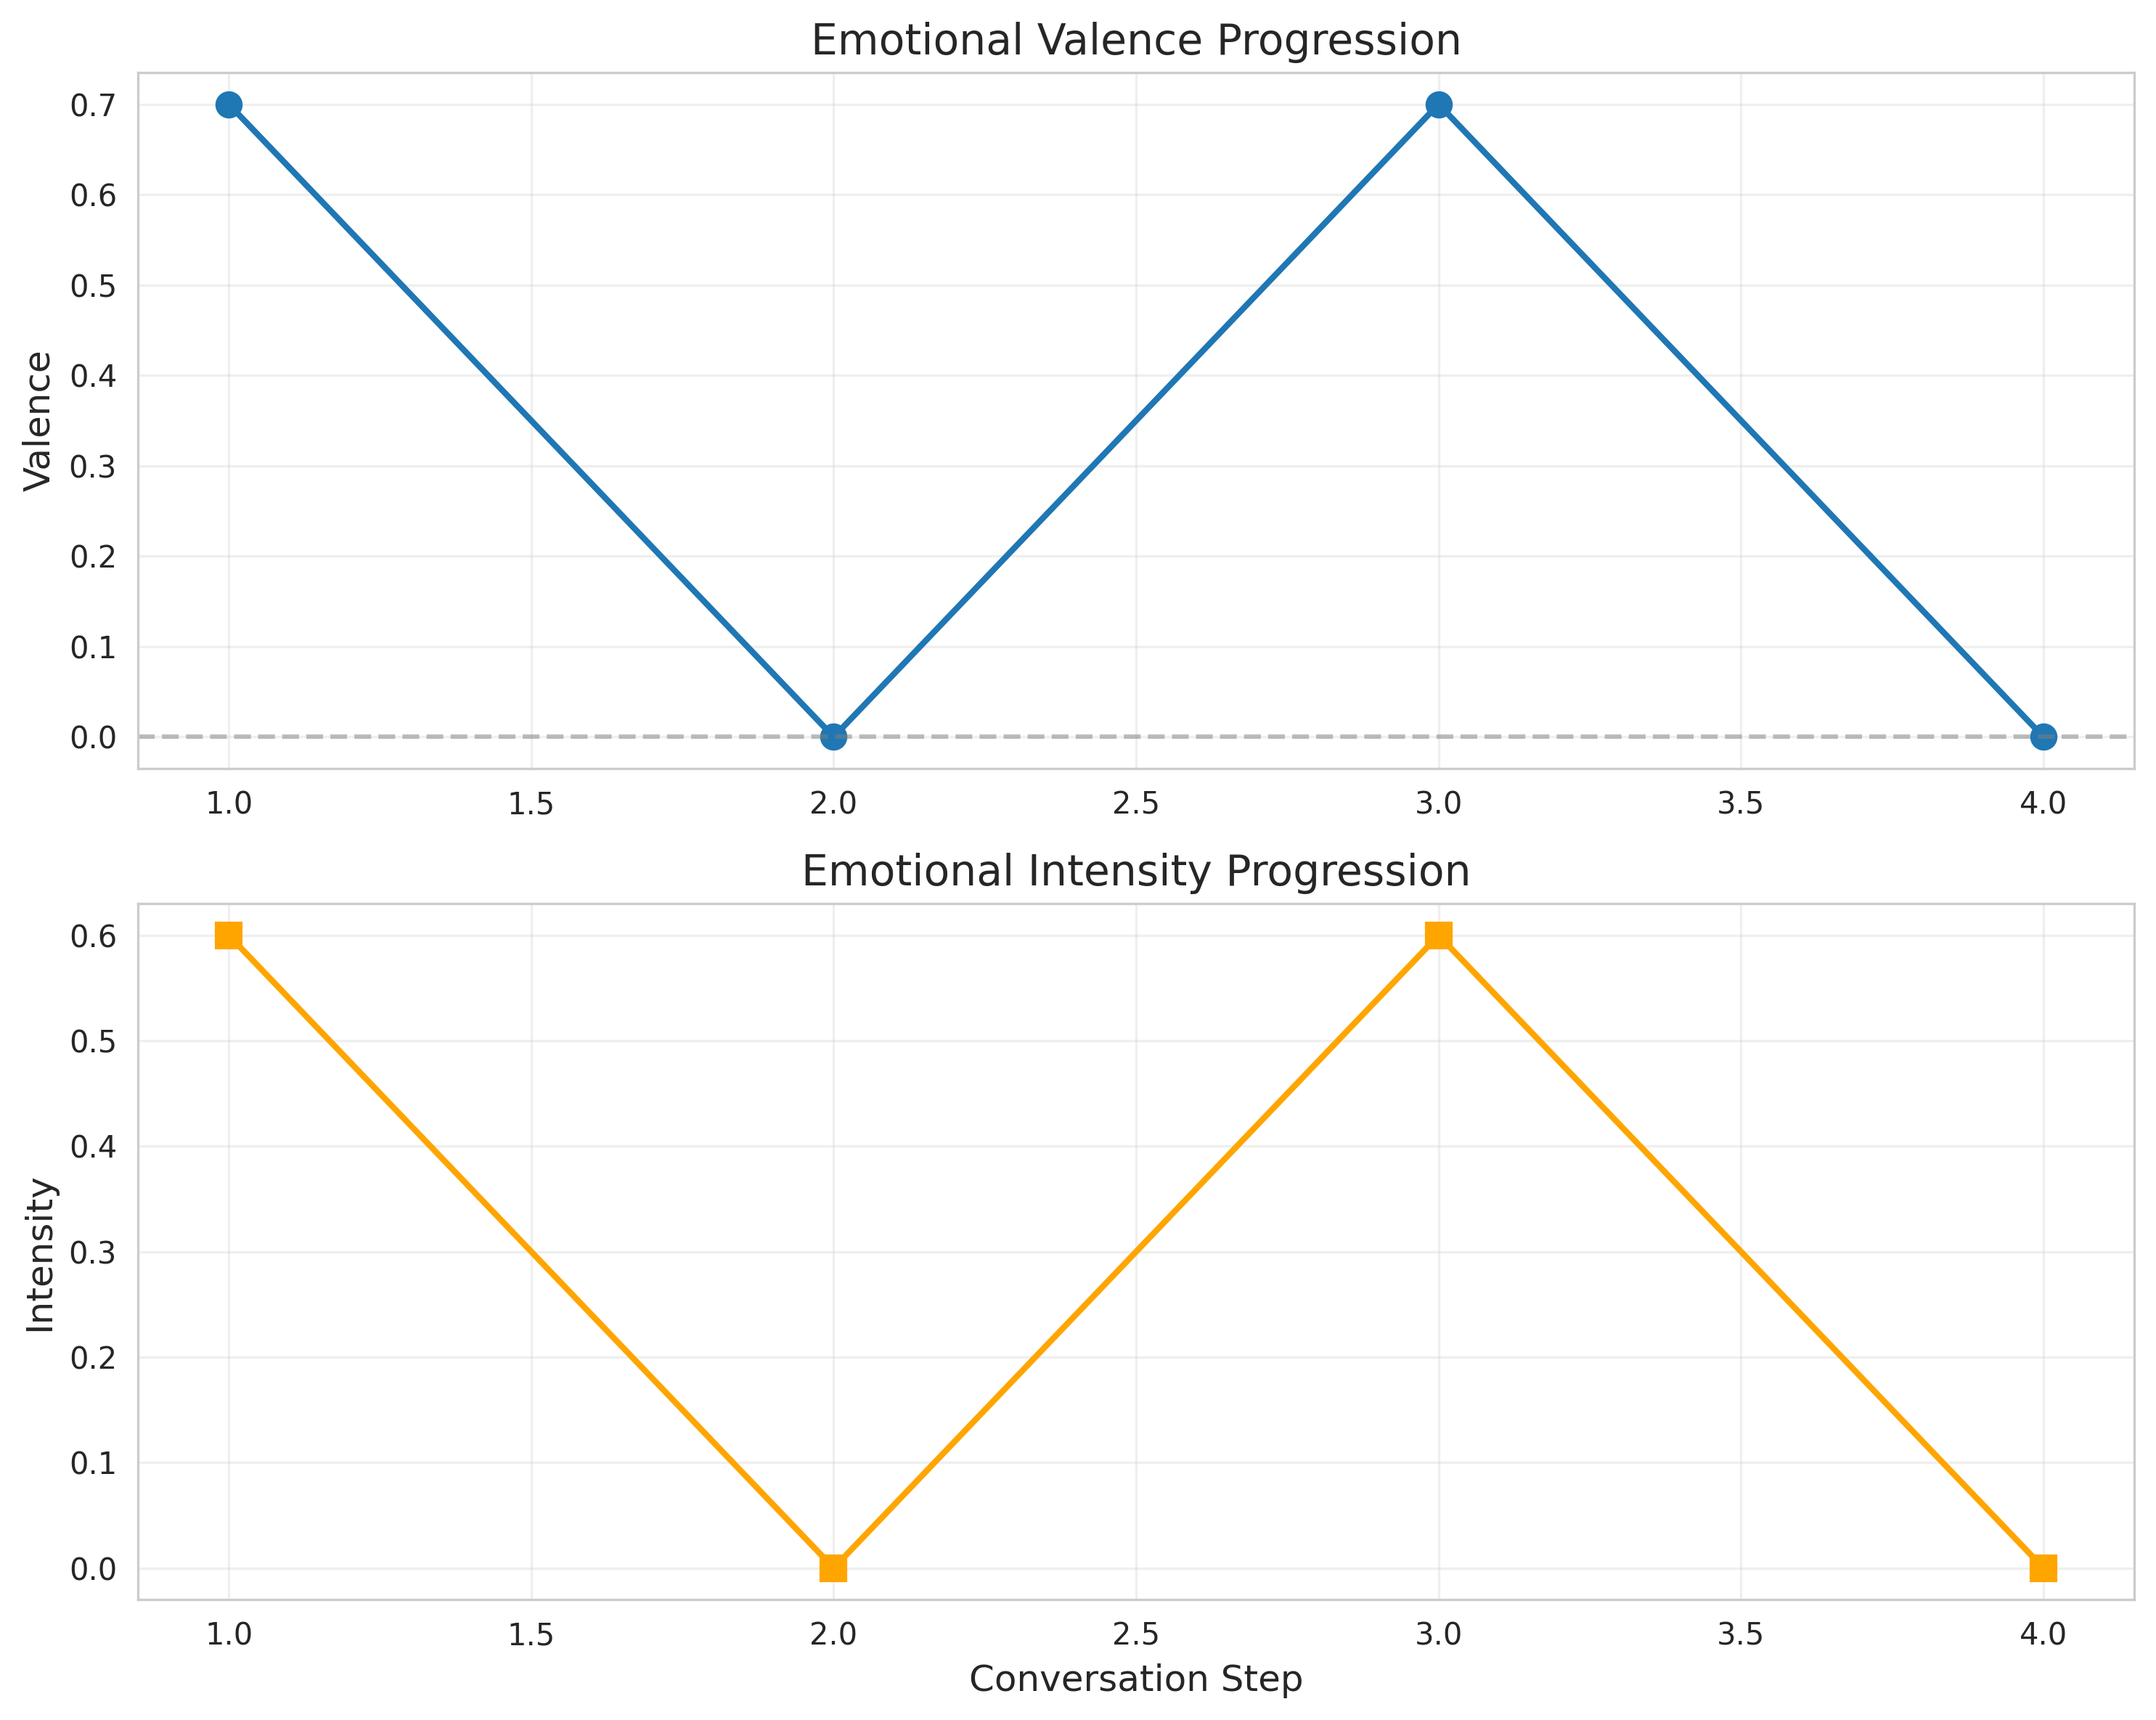


📊 Emotional arc: ['joy', 'neutral', 'hope', 'neutral']


In [10]:
# Conversation sequence
texts = [
    "I'm excited to start this project!",
    "We hit some roadblocks today, feeling a bit discouraged.",
    "After the team meeting, I feel more hopeful about finding solutions.",
    "Success! We solved the problem. Feeling accomplished.",
]

# Analyze each text in sequence
results = []
for i, text in enumerate(texts, 1):
    result = esl.process({"text": text, "format": "json"})
    emotional_state = result.get("emotional_state", {})
    
    results.append({
        "step": i,
        "text_preview": text[:50],
        "emotion": emotional_state.get("primary_emotion", "neutral"),
        "valence": emotional_state.get("valence", 0),
        "intensity": emotional_state.get("intensity", 0)
    })

# Create DataFrame for visualization
df = pd.DataFrame(results)
print(df.to_string(index=False))

# Visualize emotional progression
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Valence over time
ax1.plot(df["step"], df["valence"], marker='o', linewidth=2, markersize=8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel("Valence", fontsize=12)
ax1.set_title("Emotional Valence Progression", fontsize=14)
ax1.grid(True, alpha=0.3)

# Intensity over time
ax2.plot(df["step"], df["intensity"], marker='s', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel("Conversation Step", fontsize=12)
ax2.set_ylabel("Intensity", fontsize=12)
ax2.set_title("Emotional Intensity Progression", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("emotional_progression.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Emotional arc: {df['emotion'].tolist()}")

## Example 9: Format Options

In [11]:
# JSON format (default)
result_json = esl.process({"text": "This is wonderful!", "format": "json"})
print("JSON Format:")
print(json.dumps(result_json, indent=2))

# Summary format
result_summary = esl.process({"text": "This is wonderful!", "format": "summary"})
print("\nSummary Format:")
print(result_summary.get("summary", ""))

JSON Format:
{
  "emotional_state": {
    "primary_emotion": "joy",
    "secondary_emotions": [],
    "social_emotions": [],
    "cognitive_indicators": [],
    "valence": 0.7,
    "intensity": 0.6,
    "confidence": 0.9
  }
}

Summary Format:
Detected joy as the dominant emotion with positive valence. Overall intensity is 0.6 with a confidence of 0.9. 


## Example 10: Empathetic Response Recommendation

Generate appropriate response tones based on detected emotions.

In [12]:
def generate_empathetic_response(text: str) -> Dict[str, Any]:
    """
    Analyze user emotion and recommend appropriate response tone.
    """
    # Analyze emotion
    result = esl.process({"text": text, "format": "json"})
    emotional_state = result.get("emotional_state", {})
    
    emotion = emotional_state.get("primary_emotion", "neutral")
    valence = emotional_state.get("valence", 0)
    intensity = emotional_state.get("intensity", 0)
    
    # Determine response tone
    if valence < 0 and intensity > 0.7:
        response_tone = "empathetic"
        recommendation = "Use warm, understanding language. Acknowledge their feelings."
    elif valence > 0:
        response_tone = "encouraging"
        recommendation = "Match their positive energy. Celebrate their emotion."
    elif "confusion" in emotional_state.get("cognitive_indicators", []):
        response_tone = "clear_explanatory"
        recommendation = "Provide clear, structured explanations. Break down complex ideas."
    else:
        response_tone = "neutral_supportive"
        recommendation = "Maintain professional, supportive tone."
    
    return {
        "user_emotion": emotion,
        "valence": valence,
        "intensity": intensity,
        "recommended_tone": response_tone,
        "recommendation": recommendation
    }

# Test cases
test_cases = [
    "I'm really struggling with this. Nothing makes sense anymore.",
    "This is fantastic! Everything is going so well!",
    "I don't understand how this works. Can you explain?",
    "Just checking the status of my request.",
]

print("Empathetic Response Recommendations:")
print("=" * 80)
for text in test_cases:
    result = generate_empathetic_response(text)
    print(f"\nUser: \"{text}\"")
    print(f"Detected Emotion: {result['user_emotion']} (valence: {result['valence']:.2f}, intensity: {result['intensity']:.2f})")
    print(f"Recommended Tone: {result['recommended_tone']}")
    print(f"Guidance: {result['recommendation']}")

Empathetic Response Recommendations:

User: "I'm really struggling with this. Nothing makes sense anymore."
Detected Emotion: neutral (valence: 0.00, intensity: 0.00)
Recommended Tone: neutral_supportive
Guidance: Maintain professional, supportive tone.

User: "This is fantastic! Everything is going so well!"
Detected Emotion: joy (valence: 0.70, intensity: 0.60)
Recommended Tone: encouraging
Guidance: Match their positive energy. Celebrate their emotion.

User: "I don't understand how this works. Can you explain?"
Detected Emotion: confusion (valence: -0.70, intensity: 0.60)
Recommended Tone: clear_explanatory
Guidance: Provide clear, structured explanations. Break down complex ideas.

User: "Just checking the status of my request."
Detected Emotion: neutral (valence: 0.00, intensity: 0.00)
Recommended Tone: neutral_supportive
Guidance: Maintain professional, supportive tone.


## Example 11: Analyzing Text from Files

In [13]:
# Create sample file
sample_file = Path("sample_text.txt")
sample_file.write_text("I'm feeling overwhelmed by all these tasks.")

# Read and analyze
text = sample_file.read_text()
result = esl.process({"text": text, "format": "json"})
emotional_state = result.get("emotional_state", {})

print(f"File: {sample_file}")
print(f"Emotion: {emotional_state.get('primary_emotion')}")
print(f"Valence: {emotional_state.get('valence', 0):.2f}")

# Cleanup
sample_file.unlink()
print("\n✓ File analyzed and cleaned up")

File: sample_text.txt
Emotion: neutral
Valence: 0.00

✓ File analyzed and cleaned up


## Error Handling and Edge Cases

### Common Issues and Solutions

**Issue 1: Empty or very short text**
```python
# Problem
result = esl.process({"text": "", "format": "json"})

# Solution: Validate input first
if text.strip():
    result = esl.process({"text": text, "format": "json"})
else:
    print("Error: Empty text provided")
```

**Issue 2: Sarcasm detection**
- ESL may not detect sarcasm reliably
- "Great, just great" might read as positive
- Solution: Context from conversation history helps

**Issue 3: Cultural differences**
- Emotional expressions vary by culture
- Some emotions may be implicit
- Solution: Combine with contextual analysis

### Debugging Tips

**Check confidence scores**:
- Low confidence -> Ambiguous emotional content
- Review text for clarity

**Examine secondary emotions**:
- May reveal emotional complexity
- Helps explain mixed valence

**Track intensity over time**:
- Sudden intensity spikes -> Significant event
- Gradual changes -> Mood shifts

## Use Case Comparisons

### When to Use ESL

**Use ESL when you need to**:
- Detect emotional state in user messages
- Adjust AI response tone dynamically
- Track emotional progression over time
- Identify distress or urgent emotional states
- Build empathetic conversational systems

**Don't use ESL for**:
- Sentiment analysis of product reviews (use dedicated sentiment tools)
- Sarcasm detection (requires context beyond text)
- Emotion prediction (ESL analyzes current text only)

### Comparison with Sentiment Analysis

| Feature | ESL Emotional Analysis | Traditional Sentiment |
|---------|----------------------|---------------------|
| Dimensions | Multi (primary/social/cognitive) | Single (positive/negative) |
| Granularity | Specific emotions (joy, fear, etc.) | Binary or 3-point scale |
| Intensity | 0.0 to 1.0 scale | Usually binary |
| Use Case | Conversational AI, mental health | Product reviews, social media |

## Next Steps and Integration

### Try These Next

1. **Integrate with your chatbot**: Use ESL to detect user emotions and adjust responses
2. **Build an emotion tracker**: Monitor emotional patterns over multiple interactions
3. **Create response templates**: Map emotions to appropriate reply tones
4. **Combine with other SIM-ONE tools**: Use Five Laws Validator for governed empathetic responses

### Advanced Integration Patterns

**Pattern 1: Emotion-Driven Response Selection**
```python
def select_response_tone(user_text):
    result = esl.process({"text": user_text, "format": "json"})
    state = result["emotional_state"]
    
    if state["valence"] < -0.5 and state["intensity"] > 0.7:
        return "empathetic_supportive"
    elif state["valence"] > 0.5:
        return "enthusiastic"
    elif "confusion" in state["cognitive_indicators"]:
        return "clear_explanatory"
    else:
        return "neutral_professional"
```

**Pattern 2: Emotional Escalation Detection**
```python
def track_emotional_escalation(conversation_history):
    emotions = []
    for message in conversation_history:
        result = esl.process({"text": message, "format": "json"})
        emotions.append(result["emotional_state"]["intensity"])
    
    if emotions[-1] > 0.8 and emotions[-1] > emotions[-2]:
        return "escalating"  # Alert: User becoming more intense
```

### Learn More

- **Five Laws Validator**: Ensure your empathetic responses meet governance standards
- **REP Reasoning**: Use emotional context to inform reasoning processes
- **Governed Response Composer**: Generate emotion-appropriate, governed responses

## Summary

This tutorial demonstrated SIM-ONE's ESL protocol for emotional analysis:

### Key Capabilities
1. **Multi-dimensional emotion detection** - Primary, social, and cognitive emotions
2. **Emotional progression tracking** - Monitor changes across conversations
3. **Response recommendations** - Generate appropriate empathetic responses

### When to Use ESL
- Customer support systems - Adjust tone based on customer emotion
- Mental health applications - Track emotional states over time
- Content moderation - Detect distress or harmful emotional patterns
- Conversational AI - Generate emotionally appropriate responses

### API Reference
```python
from mcp_server.protocols.esl.esl import ESL

esl = ESL()
result = esl.process({
    "text": "Text to analyze",
    "format": "json"  # or "summary"
})
```

### Output Structure
```json
{
  "emotional_state": {
    "primary_emotion": "joy",
    "secondary_emotions": ["excitement"],
    "valence": 0.85,
    "intensity": 0.92,
    "cognitive_indicators": ["enthusiasm"]
  }
}
```